In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.rcParams["figure.figsize"] = (12,6)
sns.set_style("whitegrid")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [49]:
# Load NAV History
nav = pd.read_csv("../data/raw/02_nav_history.csv")

# Load AUM Data
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

# Load SIP Inflows
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [50]:
# NAV Dataset
print("NAV Dataset")
print(nav.head())
print(nav.shape)
print(nav.dtypes)

# AUM Dataset
print("\nAUM Dataset")
print(aum.head())
print(aum.shape)
print(aum.dtypes)

# SIP Dataset
print("\nSIP Dataset")
print(sip.head())
print(sip.shape)
print(sip.dtypes)

NAV Dataset
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
(46000, 3)
amfi_code      int64
date             str
nav          float64
dtype: object

AUM Dataset
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
(90, 5)
date                  str
fund_house            str
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object

SIP Dataset
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-0

In [51]:
print(nav.dtypes)

amfi_code      int64
date             str
nav          float64
dtype: object


In [52]:
# Convert date column to datetime format
nav["date"] = pd.to_datetime(nav["date"])

# Check the data type
print(nav.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [53]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (NAV)",
        "amfi_code": "Fund (AMFI Code)"
    }
)

# Highlight Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.1,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.1,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.show()

In [54]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


In [55]:
#CHART 2 — AUM Growth (Seaborn Bar Chart)

# Convert date to proper format
aum["date"] = pd.to_datetime(aum["date"])

# Extract year (we need yearly comparison)
aum["year"] = aum["date"].dt.year

# Check
aum.head()



,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


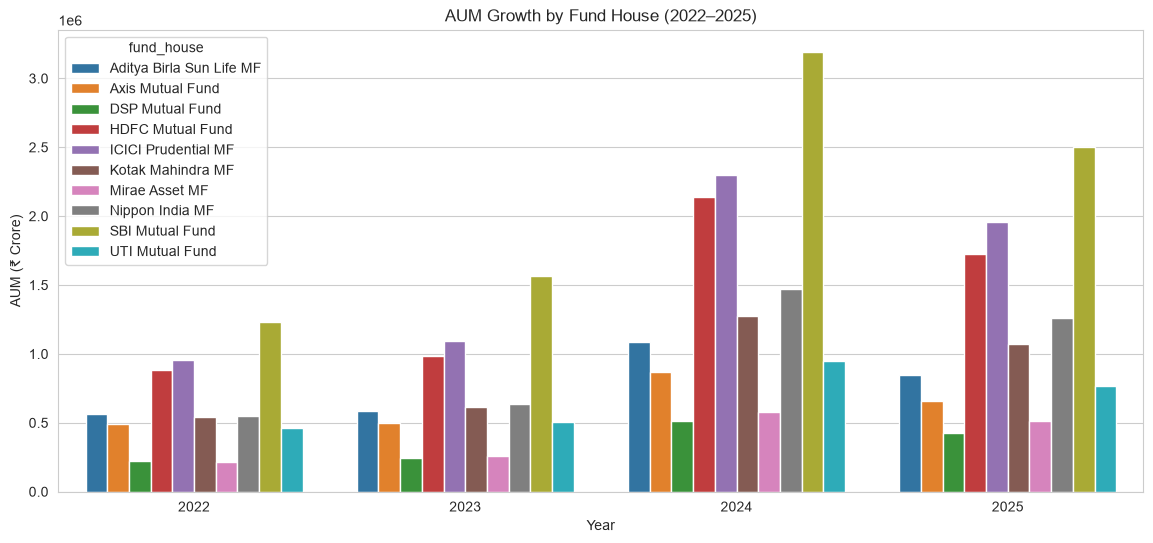

In [56]:
aum_yearly = aum.groupby(["year", "fund_house"])["aum_crore"].sum().reset_index()
aum_yearly.head()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.ylabel("AUM (₹ Crore)")
plt.xlabel("Year")

plt.show()

In [57]:
sbi_data = aum_yearly[aum_yearly["fund_house"] == "SBI Mutual Fund"]

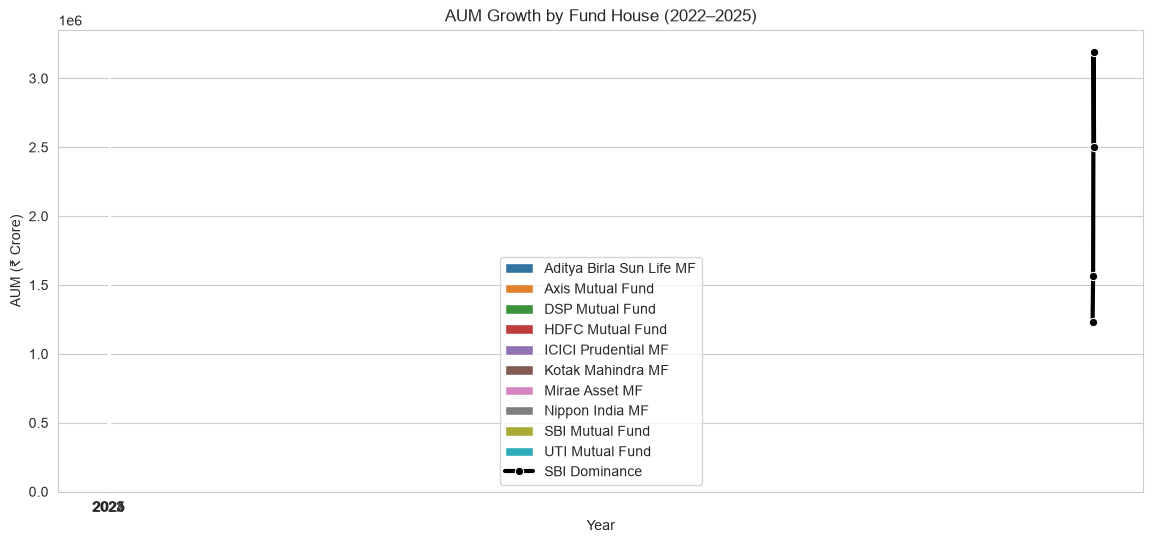

In [58]:
plt.figure(figsize=(14,6))

# All fund houses
sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

# Highlight SBI with a line on top
sns.lineplot(
    data=sbi_data,
    x="year",
    y="aum_crore",
    color="black",
    marker="o",
    linewidth=3,
    label="SBI Dominance"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.ylabel("AUM (₹ Crore)")
plt.xlabel("Year")

plt.legend()
plt.show()

In [59]:
#CHART 3 — SIP INFLOW TIME SERIES (Plotly)
sip = sip.copy()

In [60]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022–2025)"
)

In [61]:
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [62]:
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text="₹31,002 Cr Peak",
    showarrow=True,
    arrowhead=2,
    font=dict(color="green")
)
fig.show()

In [63]:
# 4 chart Category inflow heatmap
cat = pd.read_csv("../data/raw/05_category_inflows.csv")




In [64]:
cat = pd.read_csv("../data/raw/05_category_inflows.csv")
cat.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


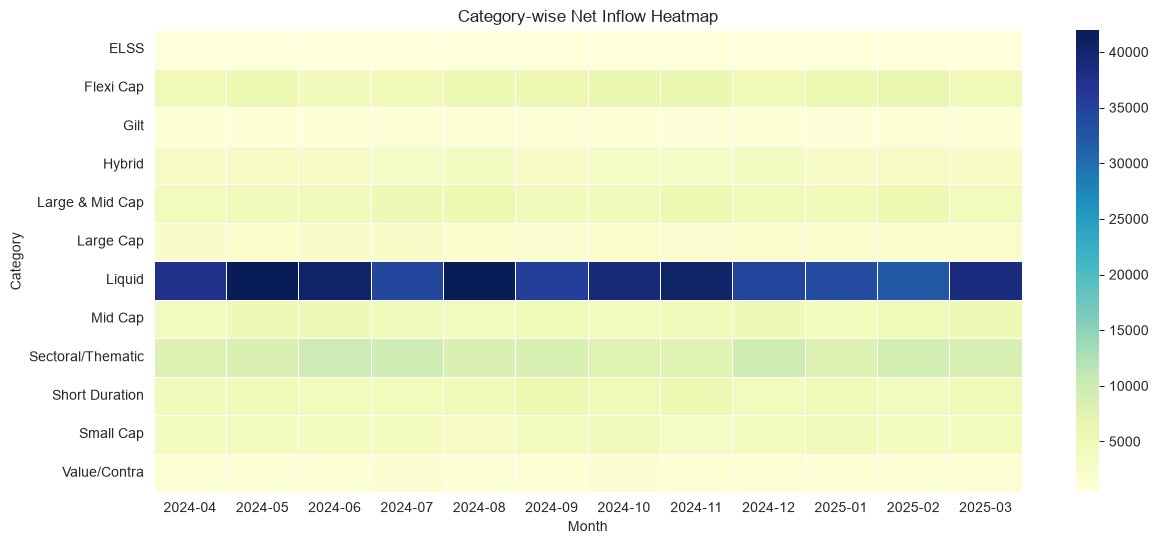

In [65]:
heatmap_data = cat.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

In [66]:
#TASK 5 — Investor Demographics
inv = pd.read_csv("../data/raw/08_investor_transactions_cleaned.csv")

In [67]:
inv.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [68]:
import plotly.express as px

gender_data = inv["gender"].value_counts().reset_index()
gender_data.columns = ["gender", "count"]

fig = px.pie(
    gender_data,
    names="gender",
    values="count",
    title="Investor Gender Distribution"
)

fig.show()

In [69]:
#BAR chart
age_data = inv["age_group"].value_counts().reset_index()
age_data.columns = ["age_group", "count"]

fig = px.bar(
    age_data,
    x="age_group",
    y="count",
    title="Investor Age Group Distribution"
)

fig.show()

In [70]:
fig = px.box(
    inv,
    x="age_group",
    y="amount_inr",
    title="SIP Amount Distribution by Age Group"
)

fig.show()

In [71]:
#TASK 6 — Geographic Distribution
import plotly.express as px

state_data = (
    inv.groupby("state")["amount_inr"]
    .sum()
    .reset_index()
    .sort_values("amount_inr", ascending=True)
)

fig = px.bar(
    state_data,
    x="amount_inr",
    y="state",
    orientation="h",
    title="Total Investment Amount by State",
    labels={
        "amount_inr": "Investment Amount (₹)",
        "state": "State"
    }
)

fig.show()

In [72]:
city_data = inv["city_tier"].value_counts().reset_index()
city_data.columns = ["city_tier", "count"]

fig = px.pie(
    city_data,
    names="city_tier",
    values="count",
    title="Investor Distribution: T30 vs B30 Cities"
)

fig.show()

In [73]:
#TASK 7 — Folio Count Growth

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [74]:
import plotly.express as px

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Growth of Total Mutual Fund Folios (2022–2025)",
    markers=True
)

fig.show()

In [75]:
max_row = folio.loc[folio["total_folios_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["total_folios_crore"],
    text=f"Peak: {max_row['total_folios_crore']} Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

In [76]:
##Insights
- Total mutual fund folios show a steady upward trend over the observed period.
- The highest folio count occurs in the latest available month, indicating growing investor participation.

SyntaxError: invalid syntax (3887925546.py, line 2)

In [ ]:
#TASK 8 — NAV Return Correlation Matrix
import pandas as pd
nav = pd.read_csv("../data/raw/02_nav_history.csv")


In [ ]:
nav["date"] = pd.to_datetime(nav["date"])


In [ ]:
selected_funds = nav["amfi_code"].unique()[:10]

nav10 = nav[nav["amfi_code"].isin(selected_funds)]

In [ ]:
pivot_nav = nav10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

In [ ]:
returns = pivot_nav.pct_change()
corr_matrix = returns.corr()

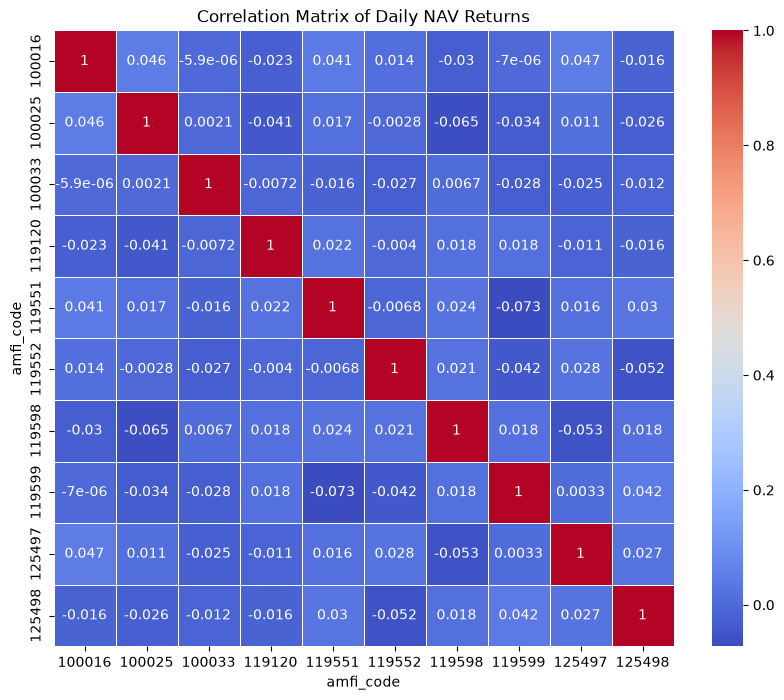

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.show()

In [ ]:
# Insight

- Most large-cap funds show positive correlation in daily returns, indicating similar market movement.
- Lower correlations suggest diversification opportunities for investors.

In [ ]:
#Sector Allocation Donut Chart

port=pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [ ]:
sector_data = (
    port.groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
)

In [ ]:
import plotly.express as px

fig = px.pie(
    sector_data,
    names="sector",
    values="weight_pct",
    title="Sector Allocation Across Equity Funds",
    hole=0.45
)

fig.show()

In [ ]:
#MARKDOWN 
# 🔍 Exploratory Data Analysis (EDA) Findings

## 1. NAV Trend Analysis
Daily NAV values showed an overall upward trend from 2022–2026, indicating long-term growth across most mutual fund schemes.

---

## 2. Fund House AUM
Among the analysed fund houses, SBI Mutual Fund maintained one of the highest Assets Under Management (AUM), reflecting strong investor confidence.

---

## 3. SIP Inflow Trend
Monthly SIP inflows generally increased over the years, showing growing participation of retail investors in mutual funds.

---

## 4. Category Inflow Analysis
The heatmap revealed that certain mutual fund categories consistently attracted higher investments across multiple months.

---

## 5. Investor Age Distribution
The majority of investors belonged to a few dominant age groups, indicating that mutual fund investments are concentrated among working-age individuals.

---

## 6. Gender Distribution
The gender distribution chart highlighted the overall composition of investors and helped understand participation across genders.

---

## 7. Geographic Distribution
Investment amounts varied significantly across states, indicating regional differences in mutual fund adoption.

---

## 8. City Tier Analysis
T30 cities contributed a larger share of investments, while B30 cities demonstrated increasing participation in mutual fund investments.

---

## 9. Folio Growth
The total number of mutual fund folios increased steadily during the observed period, reflecting continuous growth in investor participation.

---

## 10. NAV Correlation & Sector Allocation
Most selected mutual funds showed positive correlation in daily returns, while the sector allocation chart demonstrated diversified investments across multiple industries, reducing concentration risk.